In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import os

# 1. ĐỊNH NGHĨA ĐƯỜNG DẪN CÁC FILE PARQUET OOF (Bạn hãy sửa lại đường dẫn cnn nếu cần)
PATH_GAT_TRAIN = r"ip-files-train-meta\meta_X_train_xgb.parquet"
PATH_GAT_VALID = r"ip-files-train-meta\meta_X_valid_xgb.parquet"
PATH_GAT_TEST  = r"ip-files-test\meta_X_test_xgb.parquet"

PATH_CNN_TRAIN = r"ip-files-train-meta\meta_X_train_dl.parquet"
PATH_CNN_VALID = r"ip-files-train-meta\meta_X_valid_dl.parquet"
PATH_CNN_TEST  = r"ip-files-train-meta\meta_X_test_dl.parquet"

print("Đang tải dữ liệu OOF Meta-Features...")
# Tải GAT OOF
gat_train = pd.read_parquet(PATH_GAT_TRAIN, engine="pyarrow")
gat_valid = pd.read_parquet(PATH_GAT_VALID, engine="pyarrow")
gat_test  = pd.read_parquet(PATH_GAT_TEST, engine="pyarrow")

# Tải CNN OOF
cnn_train = pd.read_parquet(PATH_CNN_TRAIN, engine="pyarrow")
cnn_valid = pd.read_parquet(PATH_CNN_VALID, engine="pyarrow")
cnn_test  = pd.read_parquet(PATH_CNN_TEST, engine="pyarrow")

# Đổi tên cột để tránh trùng lặp khi concat
cnn_train.columns = [f"cnn_{col}" if col != 'label' else col for col in cnn_train.columns]
cnn_valid.columns = [f"cnn_{col}" if col != 'label' else col for col in cnn_valid.columns]
cnn_test.columns  = [f"cnn_{col}" if col != 'label' else col for col in cnn_test.columns]

gat_train.columns = [f"gat_{col}" if col != 'label' else col for col in gat_train.columns]
gat_valid.columns = [f"gat_{col}" if col != 'label' else col for col in gat_valid.columns]
gat_test.columns  = [f"gat_{col}" if col != 'label' else col for col in gat_test.columns]

print("Kích thước GAT Train:", gat_train.shape)
print("Kích thước CNN Train:", cnn_train.shape)

Đang tải dữ liệu OOF Meta-Features...
Kích thước GAT Train: (2470638, 12)
Kích thước CNN Train: (2470638, 12)


In [2]:
# 2. HỢP NHẤT META-FEATURES
print("Đang gộp Meta-Features (Concat)...")

def merge_and_clean(df_base, df_add):
    """
    Hàm hợp nhất 2 tập tính toán theo index (join='inner') và xóa NaN.
    Đảm bảo đầu ra X và y luôn đồng nhất về chiều dài.
    """
    # Ghép theo index chung, mặc định bỏ qua index không trùng khớp
    combined = pd.concat([df_base, df_add.drop(columns=['label'])], axis=1, join='inner')
    
    # Loại bỏ các dòng chứa NaN (không phải cột label)
    combined = combined.dropna(subset=[col for col in combined.columns if col != 'label'])
    # Tách X và y an toàn từ tập đã gộp
    X = combined.drop(columns=['label'])
    y = combined['label'].values
    
    return X, y

# Áp dụng hợp nhất
X_train, y_train = merge_and_clean(gat_train, cnn_train)
X_valid, y_valid = merge_and_clean(gat_valid, cnn_valid)
X_test,  y_test  = merge_and_clean(gat_test, cnn_test)

print("Kích thước X_train cuối cùng:", X_train.shape)
print("Kích thước X_valid cuối cùng:", X_valid.shape)
print("Kích thước X_test  cuối cùng:", X_test.shape)

# Tính toán Class Weights mượt (Smoothed Class Weights) cho Meta Learner nếu cần thiết
unique_classes = np.unique(y_train)
raw_class_weights = compute_class_weight('balanced', classes=unique_classes, y=y_train)
weights_dict = {c: np.sqrt(w) for c, w in zip(unique_classes, raw_class_weights)}

# Ép trọng số nhãn theo mảng Train
sample_weights_train = np.array([weights_dict[y] for y in y_train])

Đang gộp Meta-Features (Concat)...
Kích thước X_train cuối cùng: (1852947, 22)
Kích thước X_valid cuối cùng: (570125, 22)
Kích thước X_test  cuối cùng: (760231, 22)


In [3]:
import torch
print("ĐANG KHỞI ĐỘNG MÔ HÌNH STACKING XGBOOST...")

meta_model = xgb.XGBClassifier(
    n_estimators=300,      
    max_depth=2,           # Đặt độ sâu nông (Phòng thủ Meta Overfitting cực mạnh)
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42,
    device='cuda' if torch.cuda.is_available() else 'cpu', # Tự nhận diện GPU nếu có
    early_stopping_rounds=30,
    eval_metric='mlogloss'
)

print("Đang Train Meta Learner...")
meta_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=20
)

print(f"\nHuấn luyện hoàn tất! Cây quyết định dừng tối ưu ở vòng lặp thứ: {meta_model.best_iteration}")

# test trên tập Valid và Test
y_valid_pred = meta_model.predict(X_valid)
y_test_pred  = meta_model.predict(X_test)
lr_f1_valid = f1_score(y_valid, y_valid_pred, average='macro')
lr_f1_test  = f1_score(y_test, y_test_pred, average='macro')
print(f"F1 Score trên tập Valid: {lr_f1_valid:.4f}")
print(f"F1 Score trên tập Test: {lr_f1_test:.4f}")

ĐANG KHỞI ĐỘNG MÔ HÌNH STACKING XGBOOST...
Đang Train Meta Learner...
[0]	validation_0-mlogloss:1.08937	validation_1-mlogloss:1.12647
[20]	validation_0-mlogloss:0.29808	validation_1-mlogloss:0.37311
[40]	validation_0-mlogloss:0.11122	validation_1-mlogloss:0.17731
[60]	validation_0-mlogloss:0.04658	validation_1-mlogloss:0.10599
[80]	validation_0-mlogloss:0.02205	validation_1-mlogloss:0.08128
[100]	validation_0-mlogloss:0.01224	validation_1-mlogloss:0.07104
[120]	validation_0-mlogloss:0.00816	validation_1-mlogloss:0.06764
[140]	validation_0-mlogloss:0.00615	validation_1-mlogloss:0.06434
[160]	validation_0-mlogloss:0.00510	validation_1-mlogloss:0.06316
[180]	validation_0-mlogloss:0.00441	validation_1-mlogloss:0.06224
[200]	validation_0-mlogloss:0.00395	validation_1-mlogloss:0.06195
[220]	validation_0-mlogloss:0.00361	validation_1-mlogloss:0.06275

Huấn luyện hoàn tất! Cây quyết định dừng tối ưu ở vòng lặp thứ: 190


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:751: UserWarning: [23:07:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


F1 Score trên tập Valid: 0.8720
F1 Score trên tập Test: 0.8111


In [ ]:
# ============================================================
# META LEARNER TRAINING - XGBoost + Logistic Regression
# ============================================================

import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

num_classes = len(unique_classes)
print(f"\n{'='*60}")
print(f"SỐ CLASSES: {num_classes}")
print(f"SỐ FEATURES: {X_train.shape[1]}")
print(f"{'='*60}\n")

# ============================================================
# PHẦN 1: BASELINE - LOGISTIC REGRESSION
# ============================================================
print("=" * 60)
print("BASELINE: LOGISTIC REGRESSION")
print("=" * 60)

lr_model = LogisticRegression(
    C=1.0,
    max_iter=5000,
    solver='lbfgs',
    multi_class='multinomial',
    class_weight='balanced',
    random_state=42
)
lr_model.fit(X_train, y_train, sample_weight=sample_weights_train)

lr_pred_valid = lr_model.predict(X_valid)
lr_pred_test = lr_model.predict(X_test)

lr_f1_valid = f1_score(y_valid, lr_pred_valid, average='macro')
lr_f1_test = f1_score(y_test, lr_pred_test, average='macro')

print(f"LR Valid Macro F1: {lr_f1_valid:.4f}")
print(f"LR Test  Macro F1: {lr_f1_test:.4f}\n")

# ============================================================
# PHẦN 2: OPTUNA HYPERPARAMETER TUNING CHO XGBOOST META LEARNER
# ============================================================
print("=" * 60)
print("OPTUNA TUNING: XGBOOST META LEARNER")
print("=" * 60)

def objective(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': num_classes,
        'eval_metric': 'mlogloss',
        'tree_method': 'hist',       # Đổi thành 'hist' nếu không có GPU
        'device': 'cuda',                # Bỏ dòng này nếu không có GPU
        'verbosity': 0,
        'random_state': 42,
        'nthread': -1,

        # ---- Hyperparameters cần tune ----
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500, step=50),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 30),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10),
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        sample_weight=sample_weights_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    y_pred_valid = model.predict(X_valid)
    macro_f1 = f1_score(y_valid, y_pred_valid, average='macro')

    return macro_f1

# Chạy Optuna
study = optuna.create_study(
    direction='maximize',
    study_name='meta_learner_xgb',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=20)
)

study.optimize(
    objective,
    n_trials=10,          # Tăng nếu muốn tìm kỹ hơn
    show_progress_bar=True,
    n_jobs=1
)

print(f"\n{'='*60}")
print(f"BEST VALID MACRO F1: {study.best_value:.4f}")
print(f"BEST PARAMS:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"{'='*60}\n")

# ============================================================
# PHẦN 3: TRAIN FINAL MODEL VỚI BEST PARAMS
# ============================================================
print("=" * 60)
print("TRAINING FINAL META LEARNER")
print("=" * 60)

best_params = study.best_params
best_params.update({
    'objective': 'multi:softprob',
    'num_class': num_classes,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',     # Đổi 'hist' nếu không GPU
    'device': 'cuda',              # Bỏ nếu không GPU
    'verbosity': 1,
    'random_state': 42,
    'nthread': -1,
})

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=True
)

# ============================================================
# PHẦN 4: ĐÁNH GIÁ TRÊN CẢ 3 TẬP
# ============================================================
print("\n" + "=" * 60)
print("ĐÁNH GIÁ FINAL META LEARNER")
print("=" * 60)

y_pred_train = final_model.predict(X_train)
y_pred_valid = final_model.predict(X_valid)
y_pred_test  = final_model.predict(X_test)

f1_train = f1_score(y_train, y_pred_train, average='macro')
f1_valid = f1_score(y_valid, y_pred_valid, average='macro')
f1_test  = f1_score(y_test, y_pred_test, average='macro')

print(f"\n{'─'*40}")
print(f"  META XGB Train Macro F1:  {f1_train:.4f}")
print(f"  META XGB Valid Macro F1:  {f1_valid:.4f}")
print(f"  META XGB Test  Macro F1:  {f1_test:.4f}")
print(f"{'─'*40}")
print(f"  LR Baseline Valid Macro F1: {lr_f1_valid:.4f}")
print(f"  LR Baseline Test  Macro F1: {lr_f1_test:.4f}")
print(f"{'─'*40}\n")

# Classification Report cho tập Test
print("=" * 60)
print("CLASSIFICATION REPORT (TEST SET)")
print("=" * 60)
print(classification_report(y_test, y_pred_test, digits=4))

# ============================================================
# PHẦN 5: SO SÁNH BASE LEARNERS vs META LEARNER
# ============================================================
print("\n" + "=" * 60)
print("SO SÁNH TỔNG HỢP")
print("=" * 60)

comparison = pd.DataFrame({
    'Model': ['GAT_XGBoost (Base)', 'CNN-BiLSTM (Base)', 'LR Meta (Baseline)', 'XGB Meta (Final)'],
    'Valid_F1': [0.9593, 0.9443, lr_f1_valid, f1_valid],
    'Test_F1':  [0.9279, 0.8878, lr_f1_test, f1_test],
})
comparison['Gap'] = comparison['Valid_F1'] - comparison['Test_F1']
print(comparison.to_string(index=False))

# ============================================================
# PHẦN 6: VISUALIZATION
# ============================================================

# 6a. Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Meta Learner - Confusion Matrix (Test)', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('meta_confusion_matrix.png', dpi=150)
plt.show()

# 6b. Feature Importance
fig, ax = plt.subplots(figsize=(12, max(6, X_train.shape[1] * 0.3)))
importance = final_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values('Importance', ascending=True)

feat_imp.plot.barh(x='Feature', y='Importance', ax=ax, legend=False, color='steelblue')
ax.set_title('Meta Learner - Feature Importance', fontsize=14)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('meta_feature_importance.png', dpi=150)
plt.show()

# 6c. Optuna Optimization History
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.savefig('optuna_history.png', dpi=150)
plt.show()

# ============================================================
# PHẦN 7: LƯU MODEL
# ============================================================
import joblib

os.makedirs("meta_model_output", exist_ok=True)
final_model.save_model("meta_model_output/meta_xgb_final.json")
joblib.dump(lr_model, "meta_model_output/meta_lr_baseline.pkl")
joblib.dump(study.best_params, "meta_model_output/best_params.pkl")

print("\n✅ Đã lưu model tại thư mục 'meta_model_output/'")
print("   - meta_xgb_final.json")
print("   - meta_lr_baseline.pkl")
print("   - best_params.pkl")

In [ ]:
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import ParameterGrid

# Tắt cảnh báo ConvergenceWarning trong trường hợp thuật toán cần nhiều max_iter hơn để hội tụ
warnings.filterwarnings('ignore')

# 1. Định nghĩa lưới các tham số muốn thử nghiệm
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],       # Mức độ điều chuẩn (Regularization)
    'solver': ['lbfgs', 'saga', 'newton-cg'], # Các thuật toán tối ưu hỗ trợ multinomial
    'max_iter': [1000, 3000, 5000]            # Số vòng lặp tối đa
}

# ParameterGrid sẽ tự động tạo ra danh sách gồm tất cả các tổ hợp từ param_grid
grid = list(ParameterGrid(param_grid))

print("=" * 70)
print("BẮT ĐẦU VÒNG LẶP TUNING LOGISTIC REGRESSION")
print("=" * 70)

best_valid_f1 = 0
best_params = None

# 2. Chạy vòng lặp qua từng bộ tham số
for i, params in enumerate(grid, 1):
    # Khởi tạo mô hình với các tham số từ vòng lặp hiện tại
    lr_model = LogisticRegression(
        **params,
        multi_class='multinomial',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1 # Tận dụng đa luồng CPU để chạy nhanh hơn
    )
    
    # Huấn luyện mô hình (Áp dụng đúng trọng số mẫu của bạn)
    lr_model.fit(X_train, y_train, sample_weight=sample_weights_train)
    
    # Dự đoán trên tập Valid và Test
    lr_pred_valid = lr_model.predict(X_valid)
    lr_pred_test = lr_model.predict(X_test)
    
    # Tính toán Macro F1
    lr_f1_valid = f1_score(y_valid, lr_pred_valid, average='macro')
    lr_f1_test = f1_score(y_test, lr_pred_test, average='macro')
    
    # In kết quả của lần thử hiện tại
    print(f"Lần thử {i:02d}/{len(grid)} | C={params['C']}, solver={params['solver']}, max_iter={params['max_iter']}")
    print(f" -> Valid Macro F1: {lr_f1_valid:.4f} | Test Macro F1: {lr_f1_test:.4f}")
    print("-" * 70)
    
    # Lưu lại bộ tham số cho kết quả Validation F1 cao nhất
    if lr_f1_valid > best_valid_f1:
        best_valid_f1 = lr_f1_valid
        best_params = params

# 3. Tổng kết sau khi kết thúc vòng lặp
print("\n" + "=" * 70)
print("KẾT QUẢ TỐT NHẤT")
print("=" * 70)
print(f"Best Valid Macro F1 : {best_valid_f1:.4f}")
print(f"Best Parameters     : {best_params}")

BẮT ĐẦU VÒNG LẶP TUNING LOGISTIC REGRESSION
Lần thử 01/45 | C=0.01, solver=lbfgs, max_iter=1000
 -> Valid Macro F1: 0.7743 | Test Macro F1: 0.7136
----------------------------------------------------------------------


In [ ]:
# 4. ĐÁNH GIÁ CHUYÊN SÂU TRÊN TẬP TEST NGUYÊN SƠ (HOLDOUT)
print("\n=== ĐÁNH GIÁ MÔ HÌNH META LEARNER (TEST SET) ===")

y_pred = meta_model.predict(X_test)
y_pred_proba = meta_model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"Meta Learner Accuracy:        {acc * 100:.2f}%")
print(f"Meta Learner F1 (Macro):      {f1_macro * 100:.2f}%")
print(f"Meta Learner F1 (Weighted):   {f1_weighted * 100:.2f}%")

print("\n--- BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) ---")
print(classification_report(y_test, y_pred, digits=4))

# Vẽ Feature Importance của Meta Learner để xem GAT hay CNN đang đóng góp nhiều
import matplotlib.pyplot as plt
xgb.plot_importance(meta_model, max_num_features=20, height=0.8, title="Mức độ quan trọng của Features từ GAT vs CNN-BiLSTM")
plt.show()

In [14]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. TẢI DỮ LIỆU PROBABILITY TỪ 2 BASE LEARNERS
# ============================================================
print("=" * 60)
print("WEIGHTED AVERAGE BLENDING")
print("=" * 60)

# Tải lại dữ liệu (giữ nguyên đường dẫn của bạn)
PATH_GAT_VALID = r"ip-files-train-meta\meta_X_valid_xgb_old.parquet"
PATH_GAT_TEST  = r"ip-files-test\meta_X_test_xgb_old.parquet"
PATH_CNN_VALID = r"ip-files-train-meta\meta_X_valid_dl.parquet"
PATH_CNN_TEST  = r"ip-files-train-meta\meta_X_test_dl.parquet"



gat_valid = pd.read_parquet(PATH_GAT_VALID, engine="pyarrow")
gat_test  = pd.read_parquet(PATH_GAT_TEST, engine="pyarrow")
cnn_valid = pd.read_parquet(PATH_CNN_VALID, engine="pyarrow")
cnn_test  = pd.read_parquet(PATH_CNN_TEST, engine="pyarrow")


WEIGHTED AVERAGE BLENDING


In [15]:
# in ra số dòng có chứa NaN trong mỗi tập để kiểm tra
print(f"Số dòng có NaN trong GAT Valid: {gat_valid.isna().any(axis=1).sum()}")
print(f"Số dòng có NaN trong GAT Test: {gat_test.isna().any(axis=1).sum()}")
print(f"Số dòng có NaN trong CNN Valid: {cnn_valid.isna().any(axis=1).sum()}")
print(f"Số dòng có NaN trong CNN Test: {cnn_test.isna().any(axis=1).sum()}")

Số dòng có NaN trong GAT Valid: 0
Số dòng có NaN trong GAT Test: 0
Số dòng có NaN trong CNN Valid: 9
Số dòng có NaN trong CNN Test: 9


In [16]:
# xóa các dòng có NaN trong cnn_valid và cnn_test, đồng thời xóa các hàng tương ứng trong gat_valid và gat_test để đảm bảo đồng nhất
cnn_valid = cnn_valid.dropna()
cnn_test = cnn_test.dropna()
gat_valid = gat_valid.loc[cnn_valid.index]
gat_test = gat_test.loc[cnn_test.index]

Số classes: 11
GAT Valid proba shape: (570125, 11)
CNN Valid proba shape: (570125, 11)
GAT Test proba shape:  (760231, 11)
CNN Test proba shape:  (760231, 11)

PHƯƠNG PHÁP 1: GRID SEARCH WEIGHT

✅ Best Weight (theo Valid F1):
   GAT weight: 0.96
   CNN weight: 0.04
   Valid Macro F1: 0.9598
   Test Macro F1:  0.9286

PHƯƠNG PHÁP 2: SCIPY OPTIMIZE

✅ Optimized Weights:
   GAT weight: 0.7000
   CNN weight: 0.3000
   Valid Macro F1: 0.9499
   Test Macro F1:  0.9169

TOP 10 WEIGHTS (THEO VALID F1)
 w_gat  w_cnn  valid_f1  test_f1
  0.96   0.04  0.959763 0.928570
  0.95   0.05  0.959740 0.928688
  0.97   0.03  0.959736 0.928467
  0.93   0.07  0.959664 0.928832
  0.94   0.06  0.959655 0.928830
  0.98   0.02  0.959616 0.928372
  0.99   0.01  0.959462 0.928201
  0.92   0.08  0.959449 0.928810
  0.91   0.09  0.959340 0.928802
  1.00   0.00  0.959274 0.927920

SO SÁNH TỔNG HỢP
                  Model  Valid_F1  Test_F1      Gap
     GAT_XGBoost (Base)  0.959300 0.927900 0.031400
      CNN-BiLSTM

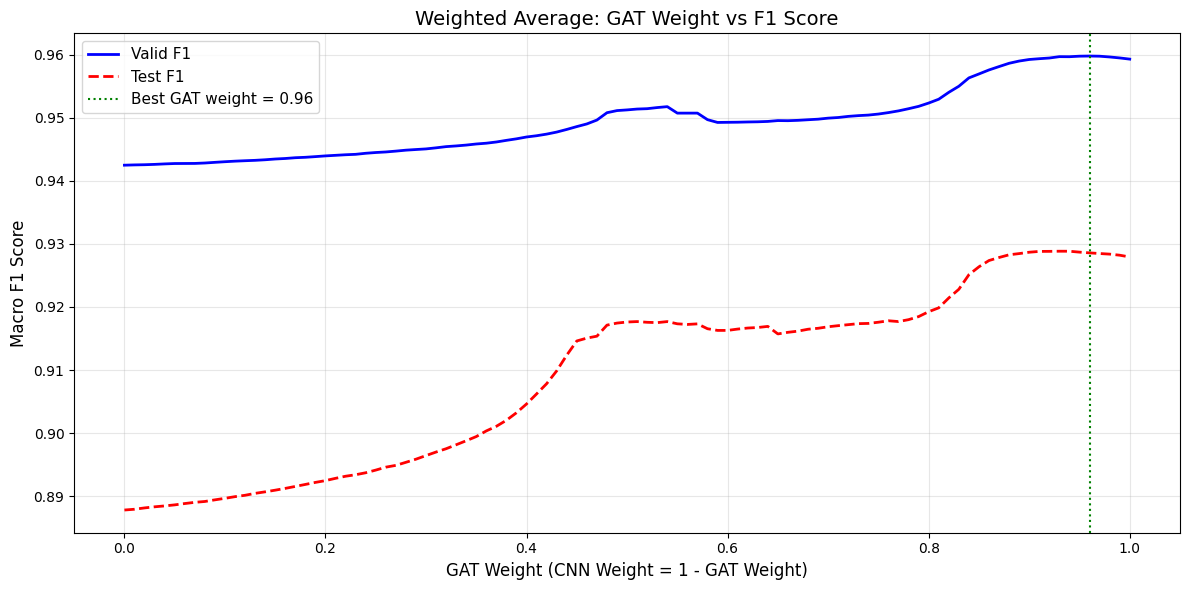


CLASSIFICATION REPORT (TEST) - Weight GAT=0.96
              precision    recall  f1-score   support

           0     0.7625    0.9755    0.8559     19846
           1     0.9890    1.0000    0.9945    484077
           2     1.0000    0.9984    0.9992      2515
           3     0.9980    0.9910    0.9945     36253
           4     0.7757    0.8792    0.8242     18979
           5     1.0000    0.9988    0.9994      2451
           6     0.9467    0.6995    0.8045     11847
           7     1.0000    1.0000    1.0000    107436
           8     0.8795    0.9728    0.9238     16746
           9     0.9950    0.7280    0.8409     41514
          10     0.9981    0.9575    0.9774     18567

    accuracy                         0.9747    760231
   macro avg     0.9404    0.9273    0.9286    760231
weighted avg     0.9773    0.9747    0.9741    760231



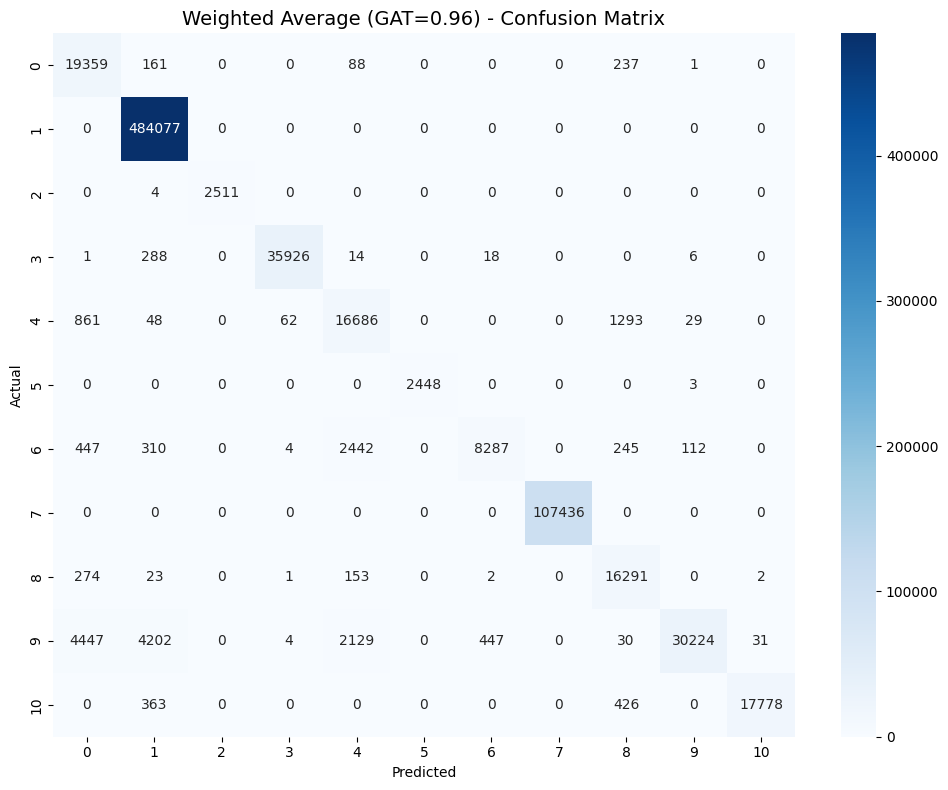


✅ Hoàn tất! Đã lưu biểu đồ.


In [17]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')




# Tách label và probability columns
y_valid = gat_valid['label'].values
y_test  = gat_test['label'].values

# Lấy cột probability (tất cả cột trừ 'label')
gat_valid_proba = gat_valid.drop(columns=['label']).values
gat_test_proba  = gat_test.drop(columns=['label']).values
cnn_valid_proba = cnn_valid.drop(columns=['label']).values
cnn_test_proba  = cnn_test.drop(columns=['label']).values

num_classes = gat_valid_proba.shape[1]
print(f"Số classes: {num_classes}")
print(f"GAT Valid proba shape: {gat_valid_proba.shape}")
print(f"CNN Valid proba shape: {cnn_valid_proba.shape}")
print(f"GAT Test proba shape:  {gat_test_proba.shape}")
print(f"CNN Test proba shape:  {cnn_test_proba.shape}")

# ============================================================
# 2. PHƯƠNG PHÁP 1: GRID SEARCH WEIGHT (ĐƠN GIẢN, TRỰC QUAN)
# ============================================================
print("\n" + "=" * 60)
print("PHƯƠNG PHÁP 1: GRID SEARCH WEIGHT")
print("=" * 60)

best_f1 = 0
best_w_gat = 0
results = []

# Duyệt weight GAT từ 0.0 → 1.0, bước 0.01
for w_gat in np.arange(0.0, 1.01, 0.01):
    w_cnn = 1.0 - w_gat
    
    # Blend probabilities trên VALID set
    blended_valid = w_gat * gat_valid_proba + w_cnn * cnn_valid_proba
    preds_valid = np.argmax(blended_valid, axis=1)
    f1_val = f1_score(y_valid, preds_valid, average='macro')
    
    # Blend probabilities trên TEST set (chỉ để theo dõi, KHÔNG dùng để chọn weight)
    blended_test = w_gat * gat_test_proba + w_cnn * cnn_test_proba
    preds_test = np.argmax(blended_test, axis=1)
    f1_tst = f1_score(y_test, preds_test, average='macro')
    
    results.append({
        'w_gat': round(w_gat, 2),
        'w_cnn': round(w_cnn, 2),
        'valid_f1': f1_val,
        'test_f1': f1_tst
    })
    
    if f1_val > best_f1:
        best_f1 = f1_val
        best_w_gat = w_gat

best_w_cnn = 1.0 - best_w_gat
results_df = pd.DataFrame(results)

print(f"\n✅ Best Weight (theo Valid F1):")
print(f"   GAT weight: {best_w_gat:.2f}")
print(f"   CNN weight: {best_w_cnn:.2f}")
print(f"   Valid Macro F1: {best_f1:.4f}")

# Áp dụng best weight lên Test
final_blended_test = best_w_gat * gat_test_proba + best_w_cnn * cnn_test_proba
final_preds_test = np.argmax(final_blended_test, axis=1)
final_test_f1 = f1_score(y_test, final_preds_test, average='macro')
print(f"   Test Macro F1:  {final_test_f1:.4f}")

# ============================================================
# 3. PHƯƠNG PHÁP 2: SCIPY OPTIMIZE (CHÍNH XÁC HƠN)
# ============================================================
print("\n" + "=" * 60)
print("PHƯƠNG PHÁP 2: SCIPY OPTIMIZE")
print("=" * 60)

def neg_f1_valid(weights):
    """Hàm mục tiêu: tối thiểu hóa -F1 trên valid set"""
    w_gat, w_cnn = weights
    blended = w_gat * gat_valid_proba + w_cnn * cnn_valid_proba
    preds = np.argmax(blended, axis=1)
    return -f1_score(y_valid, preds, average='macro')

# Optimize với constraint: w_gat + w_cnn = 1
result = minimize(
    neg_f1_valid,
    x0=[0.7, 0.3],           # Khởi tạo: ưu tiên GAT
    method='SLSQP',
    bounds=[(0, 1), (0, 1)],  # Mỗi weight trong [0, 1]
    constraints={'type': 'eq', 'fun': lambda w: w[0] + w[1] - 1.0}
)

opt_w_gat, opt_w_cnn = result.x
opt_blended_valid = opt_w_gat * gat_valid_proba + opt_w_cnn * cnn_valid_proba
opt_preds_valid = np.argmax(opt_blended_valid, axis=1)
opt_f1_valid = f1_score(y_valid, opt_preds_valid, average='macro')

opt_blended_test = opt_w_gat * gat_test_proba + opt_w_cnn * cnn_test_proba
opt_preds_test = np.argmax(opt_blended_test, axis=1)
opt_f1_test = f1_score(y_test, opt_preds_test, average='macro')

print(f"\n✅ Optimized Weights:")
print(f"   GAT weight: {opt_w_gat:.4f}")
print(f"   CNN weight: {opt_w_cnn:.4f}")
print(f"   Valid Macro F1: {opt_f1_valid:.4f}")
print(f"   Test Macro F1:  {opt_f1_test:.4f}")

# ============================================================
# 4. TOP 10 WEIGHTS THEO VALID F1
# ============================================================
print("\n" + "=" * 60)
print("TOP 10 WEIGHTS (THEO VALID F1)")
print("=" * 60)
top10 = results_df.sort_values('valid_f1', ascending=False).head(10)
print(top10.to_string(index=False))

# ============================================================
# 5. SO SÁNH TỔNG HỢP
# ============================================================
print("\n" + "=" * 60)
print("SO SÁNH TỔNG HỢP")
print("=" * 60)

comparison = pd.DataFrame({
    'Model': [
        'GAT_XGBoost (Base)',
        'CNN-BiLSTM (Base)',
        'XGB Meta (Stacking)',
        f'Weighted Avg (GAT={best_w_gat:.2f})',
        f'Scipy Opt (GAT={opt_w_gat:.4f})',
    ],
    'Valid_F1': [0.9593, 0.9418, 0.9704, best_f1, opt_f1_valid],
    'Test_F1':  [0.9279, 0.8700, 0.8875, final_test_f1, opt_f1_test],
})
comparison['Gap'] = comparison['Valid_F1'] - comparison['Test_F1']
print(comparison.to_string(index=False))

# ============================================================
# 6. VISUALIZATION
# ============================================================

# 6a. Weight vs F1 Score
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(results_df['w_gat'], results_df['valid_f1'], 
        label='Valid F1', color='blue', linewidth=2)
ax.plot(results_df['w_gat'], results_df['test_f1'], 
        label='Test F1', color='red', linewidth=2, linestyle='--')
ax.axvline(x=best_w_gat, color='green', linestyle=':', 
           label=f'Best GAT weight = {best_w_gat:.2f}')
ax.set_xlabel('GAT Weight (CNN Weight = 1 - GAT Weight)', fontsize=12)
ax.set_ylabel('Macro F1 Score', fontsize=12)
ax.set_title('Weighted Average: GAT Weight vs F1 Score', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('weighted_avg_search.png', dpi=150)
plt.show()

# 6b. Classification Report cho best weight
print("\n" + "=" * 60)
print(f"CLASSIFICATION REPORT (TEST) - Weight GAT={best_w_gat:.2f}")
print("=" * 60)
print(classification_report(y_test, final_preds_test, digits=4))

# 6c. Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, final_preds_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Weighted Average (GAT={best_w_gat:.2f}) - Confusion Matrix', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('weighted_avg_confusion_matrix.png', dpi=150)
plt.show()

print("\n✅ Hoàn tất! Đã lưu biểu đồ.")

In [ ]:
from sklearn.metrics import f1_score


test_preds_gat = gat_test.drop(columns=['label']).values
test_labels_gat = gat_test['label'].values

macro_f1_score_gat = f1_score(test_labels_gat, np.argmax(test_preds_gat, axis=1), average='macro')
print(f"GAT_XGBoost test Macro F1 Score: {macro_f1_score_gat:.4f}")

cnn_test = cnn_test.dropna(subset=['cnn_dl_class_0'], axis = 0)  # xóa các dòng có giá trị NaN ở cột cnn_dl_class_0

test_preds_cnn = cnn_test.drop(columns=['label']).values
test_labels_cnn = cnn_test['label'].values
macro_f1_score_cnn = f1_score(test_labels_cnn, np.argmax(test_preds_cnn, axis=1), average='macro')
print(f"CNN-BiLSTM test Macro F1 Score: {macro_f1_score_cnn:.4f}")


valid_preds_gat = gat_valid.drop(columns=['label']).values
valid_labels_gat = gat_valid['label'].values
macro_f1_score_gat_valid = f1_score(valid_labels_gat, np.argmax(valid_preds_gat, axis=1), average='macro')
print(f"GAT_XGBoost valid Macro F1 Score: {macro_f1_score_gat_valid:.4f}")


cnn_valid = cnn_valid.dropna(subset=['cnn_dl_class_0'], axis = 0)  # xóa các dòng có giá trị NaN ở cột cnn_dl_class_0
valid_preds_cnn = cnn_valid.drop(columns=['label']).values
valid_labels_cnn = cnn_valid['label'].values
macro_f1_score_cnn_valid = f1_score(valid_labels_cnn, np.argmax(valid_preds_cnn, axis=1), average='macro')
print(f"CNN-BiLSTM valid Macro F1 Score: {macro_f1_score_cnn_valid:.4f}")


# xóa các dòng mà cột cnn_dl_class_0 có giá trị NaN trong tập cnn_train
cnn_train = cnn_train.dropna(subset=['cnn_dl_class_0'], axis = 0)

# xóa các dòng mà cột gat_xgb_class_0 có giá trị NaN trong tập gat_train
gat_train = gat_train.dropna(subset=['gat_xgb_class_0'], axis = 0)



train_preds_gat = gat_train.drop(columns=['label']).values
train_labels_gat = gat_train['label'].values
macro_f1_score_gat_train = f1_score(train_labels_gat, np.argmax(train_preds_gat, axis=1), average='macro')
print(f"GAT_XGBoost train Macro F1 Score (train theo phương pháp OOF nên điểm thấp): {macro_f1_score_gat_train:.4f}")

train_preds_cnn = cnn_train.drop(columns=['label']).values
train_labels_cnn = cnn_train['label'].values
macro_f1_score_cnn_train = f1_score(train_labels_cnn, np.argmax(train_preds_cnn, axis=1), average='macro')
print(f"CNN-BiLSTM train Macro F1 Score(train theo phương pháp OOF nên điểm thấp hơn chút): {macro_f1_score_cnn_train:.4f}")
